# 1章 入門チュートリアル

## MNE-PythonによるMEG/EEG解析の概要

### pythonモジュールのインポート

In [21]:
import numpy as np

import mne

In [3]:
import mne 
import matplotlib 
print("MNE:", mne.__version__) 
print("matplotlib:", matplotlib.__version__)

MNE: 1.12.0
matplotlib: 3.10.5


In [3]:
import lzma

In [6]:
import pyvistaqt
import nibabel

### データの読み込み

In [7]:
# プログラム1
sample_data_folder = mne.datasets.sample.data_path()
sample_data_raw_file = (
    sample_data_folder / "MEG" / "sample" / "sample_audvis_filt-0-40_raw.fif"
)
raw = mne.io.read_raw_fif(sample_data_raw_file)

Opening raw data file /Users/r.shimbo/mne_data/MNE-sample-data/MEG/sample/sample_audvis_filt-0-40_raw.fif...
    Read a total of 4 projection items:
        PCA-v1 (1 x 102)  idle
        PCA-v2 (1 x 102)  idle
        PCA-v3 (1 x 102)  idle
        Average EEG reference (1 x 60)  idle
    Range : 6450 ... 48149 =     42.956 ...   320.665 secs
Ready.


/Users/r.shimbo/Desktop/MNE Python/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [8]:
# プログラム2
print(raw)
print(raw.info)

<Raw | sample_audvis_filt-0-40_raw.fif, 376 x 41700 (277.7 s), ~3.2 MiB, data not loaded>
<Info | 15 non-empty values
 bads: 2 items (MEG 2443, EEG 053)
 ch_names: MEG 0113, MEG 0112, MEG 0111, MEG 0122, MEG 0123, MEG 0121, MEG ...
 chs: 204 Gradiometers, 102 Magnetometers, 9 Stimulus, 60 EEG, 1 EOG
 custom_ref_applied: False
 dev_head_t: MEG device -> head transform
 dig: 146 items (3 Cardinal, 4 HPI, 61 EEG, 78 Extra)
 file_id: 4 items (dict)
 highpass: 0.1 Hz
 hpi_meas: 1 item (list)
 hpi_results: 1 item (list)
 lowpass: 40.0 Hz
 meas_date: 2002-12-03 19:01:10 UTC
 meas_id: 4 items (dict)
 nchan: 376
 projs: PCA-v1: off, PCA-v2: off, PCA-v3: off, Average EEG reference: off
 sfreq: 150.2 Hz
>


Effective window size : 13.639 (s)
Plotting power spectral density (dB=True).
Using matplotlib as 2D backend.


/Users/r.shimbo/Desktop/MNE Python/.venv/lib/python3.12/site-packages/mne/viz/utils.py:160: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  (fig or plt).show(**kwargs)
/Users/r.shimbo/Desktop/MNE Python/.venv/lib/python3.12/site-packages/mne/viz/_figure.py:385: RuntimeWarning: divide by zero encountered in matmul
  data = self.mne.projector @ data
/Users/r.shimbo/Desktop/MNE Python/.venv/lib/python3.12/site-packages/mne/viz/_figure.py:385: RuntimeWarning: overflow encountered in matmul
  data = self.mne.projector @ data
/Users/r.shimbo/Desktop/MNE Python/.venv/lib/python3.12/site-packages/mne/viz/_figure.py:385: RuntimeWarning: invalid value encountered in matmul
  data = self.mne.projector @ data


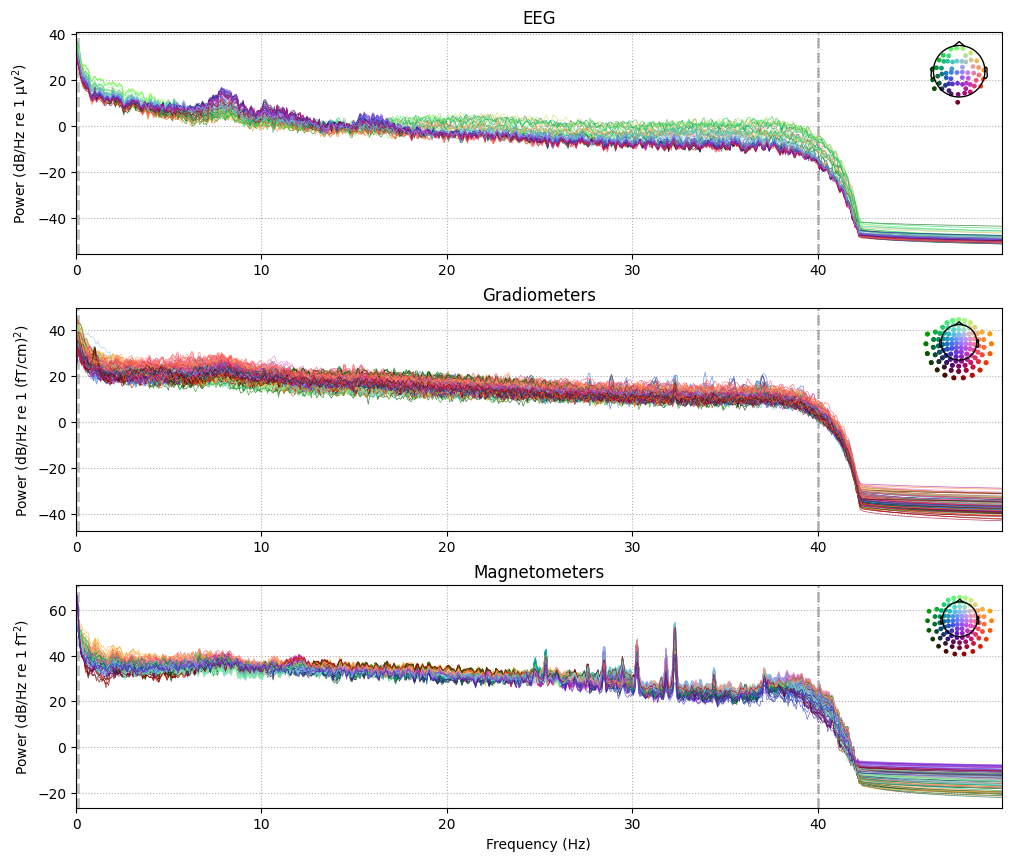

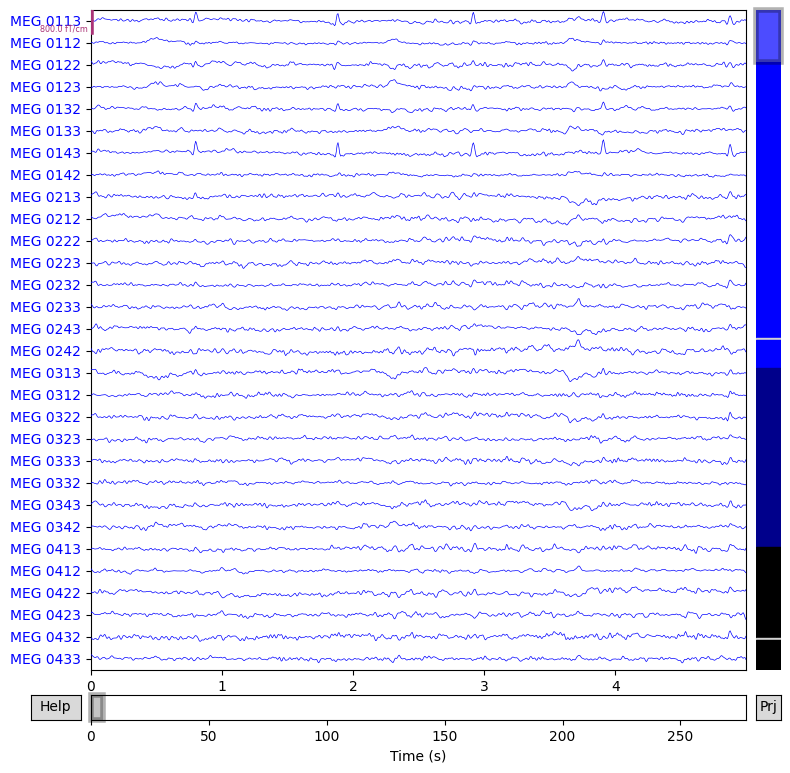

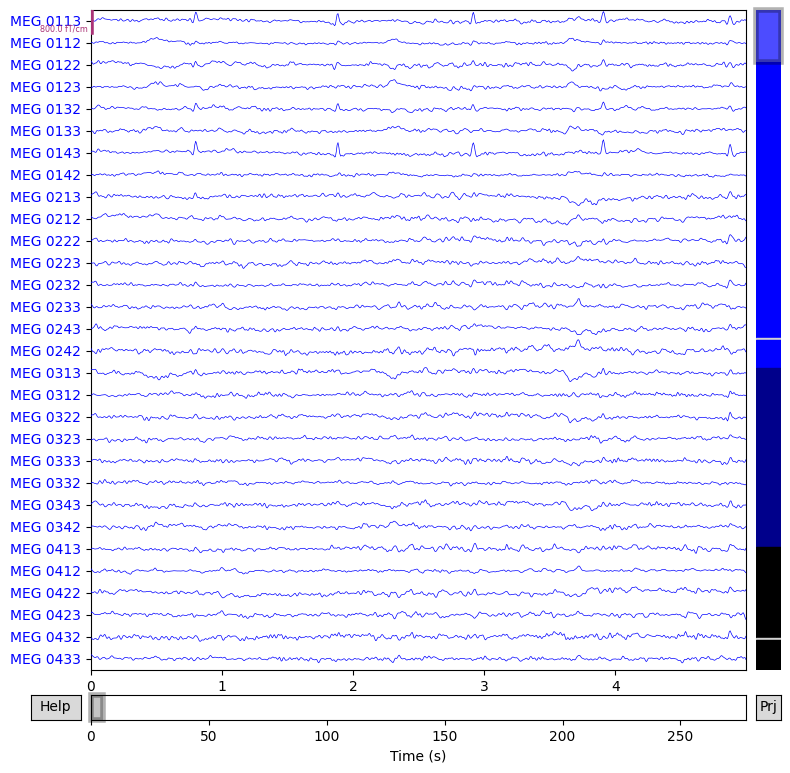

In [9]:
# プログラム3
raw.compute_psd(fmax=50).plot(picks="data", exclude="bads", amplitude=False)
raw.plot(duration=5, n_channels=30)

### 前処理

Fitting ICA to data using 364 channels (please be patient, this may take a while)
Selecting by number: 20 components


/Users/r.shimbo/Desktop/MNE Python/.venv/lib/python3.12/site-packages/scipy/linalg/_basic.py:1648: RuntimeWarning: divide by zero encountered in matmul
  B = (u @ vh[:rank]).conj().T
/Users/r.shimbo/Desktop/MNE Python/.venv/lib/python3.12/site-packages/scipy/linalg/_basic.py:1648: RuntimeWarning: overflow encountered in matmul
  B = (u @ vh[:rank]).conj().T
/Users/r.shimbo/Desktop/MNE Python/.venv/lib/python3.12/site-packages/scipy/linalg/_basic.py:1648: RuntimeWarning: invalid value encountered in matmul
  B = (u @ vh[:rank]).conj().T
/Users/r.shimbo/Desktop/MNE Python/.venv/lib/python3.12/site-packages/mne/utils/linalg.py:286: RuntimeWarning: divide by zero encountered in matmul
  return (u @ vh[:rank]).conj().T
/Users/r.shimbo/Desktop/MNE Python/.venv/lib/python3.12/site-packages/mne/utils/linalg.py:286: RuntimeWarning: overflow encountered in matmul
  return (u @ vh[:rank]).conj().T
/Users/r.shimbo/Desktop/MNE Python/.venv/lib/python3.12/site-packages/mne/utils/linalg.py:286: Runti

Fitting ICA took 2.1s.
    Using multitaper spectrum estimation with 7 DPSS windows
Not setting metadata
138 matching events found
No baseline correction applied
0 projection items activated


/Users/r.shimbo/Desktop/MNE Python/.venv/lib/python3.12/site-packages/scipy/_lib/array_api_compat/common/_aliases.py:552: RuntimeWarning: divide by zero encountered in matmul
  return xp.matmul(x1, x2, **kwargs)
/Users/r.shimbo/Desktop/MNE Python/.venv/lib/python3.12/site-packages/scipy/_lib/array_api_compat/common/_aliases.py:552: RuntimeWarning: overflow encountered in matmul
  return xp.matmul(x1, x2, **kwargs)
/Users/r.shimbo/Desktop/MNE Python/.venv/lib/python3.12/site-packages/scipy/_lib/array_api_compat/common/_aliases.py:552: RuntimeWarning: invalid value encountered in matmul
  return xp.matmul(x1, x2, **kwargs)


Not setting metadata
138 matching events found
No baseline correction applied
0 projection items activated


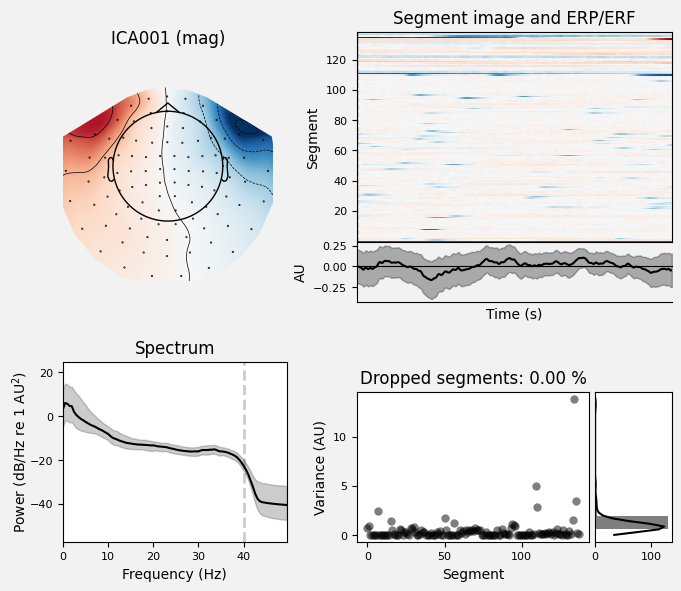

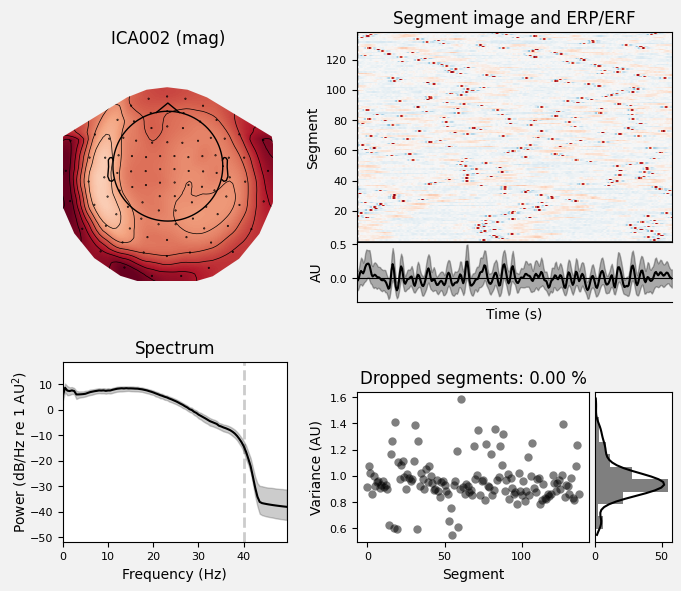

[<Figure size 700x600 with 6 Axes>, <Figure size 700x600 with 6 Axes>]

In [10]:
# プログラム4

# set up and fit the ICA
ica = mne.preprocessing.ICA(n_components=20, random_state=97, max_iter=800)
ica.fit(raw)
ica.exclude = [1, 2]  # details on how we picked these are omitted here
ica.plot_properties(raw, picks=ica.exclude)

Reading 0 ... 41699  =      0.000 ...   277.709 secs...
Applying ICA to Raw instance
    Transforming to ICA space (20 components)
    Zeroing out 2 ICA components
    Projecting back using 364 PCA components


/Users/r.shimbo/Desktop/MNE Python/.venv/lib/python3.12/site-packages/mne/preprocessing/ica.py:2403: RuntimeWarning: divide by zero encountered in matmul
  mixing = pca_components.T @ mixing
/Users/r.shimbo/Desktop/MNE Python/.venv/lib/python3.12/site-packages/mne/preprocessing/ica.py:2403: RuntimeWarning: overflow encountered in matmul
  mixing = pca_components.T @ mixing
/Users/r.shimbo/Desktop/MNE Python/.venv/lib/python3.12/site-packages/mne/preprocessing/ica.py:2403: RuntimeWarning: invalid value encountered in matmul
  mixing = pca_components.T @ mixing
/Users/r.shimbo/Desktop/MNE Python/.venv/lib/python3.12/site-packages/mne/viz/_figure.py:385: RuntimeWarning: divide by zero encountered in matmul
  data = self.mne.projector @ data
/Users/r.shimbo/Desktop/MNE Python/.venv/lib/python3.12/site-packages/mne/viz/_figure.py:385: RuntimeWarning: overflow encountered in matmul
  data = self.mne.projector @ data
/Users/r.shimbo/Desktop/MNE Python/.venv/lib/python3.12/site-packages/mne/vi

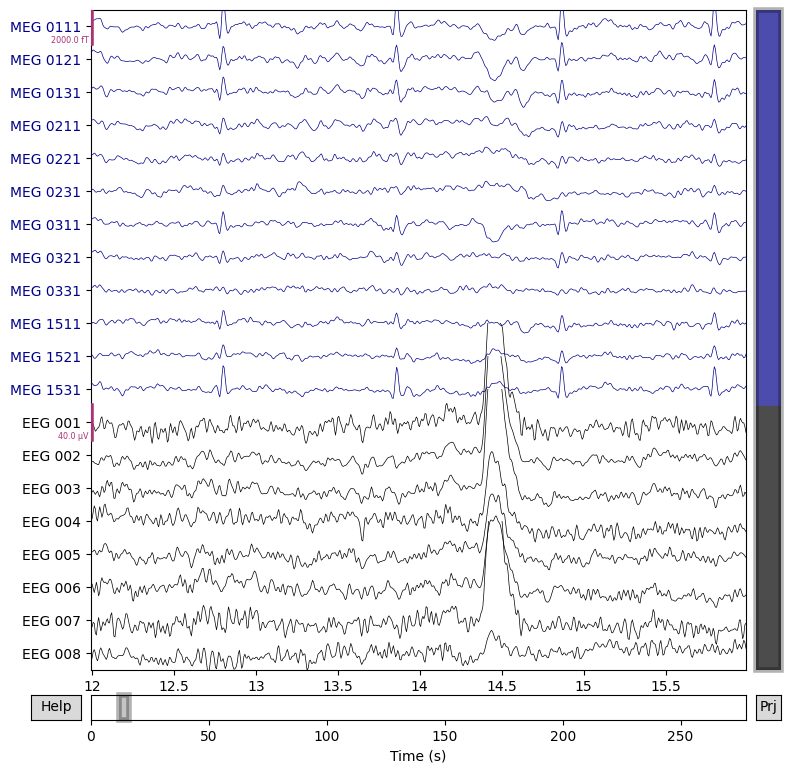

/Users/r.shimbo/Desktop/MNE Python/.venv/lib/python3.12/site-packages/mne/viz/_figure.py:385: RuntimeWarning: divide by zero encountered in matmul
  data = self.mne.projector @ data
/Users/r.shimbo/Desktop/MNE Python/.venv/lib/python3.12/site-packages/mne/viz/_figure.py:385: RuntimeWarning: overflow encountered in matmul
  data = self.mne.projector @ data
/Users/r.shimbo/Desktop/MNE Python/.venv/lib/python3.12/site-packages/mne/viz/_figure.py:385: RuntimeWarning: invalid value encountered in matmul
  data = self.mne.projector @ data


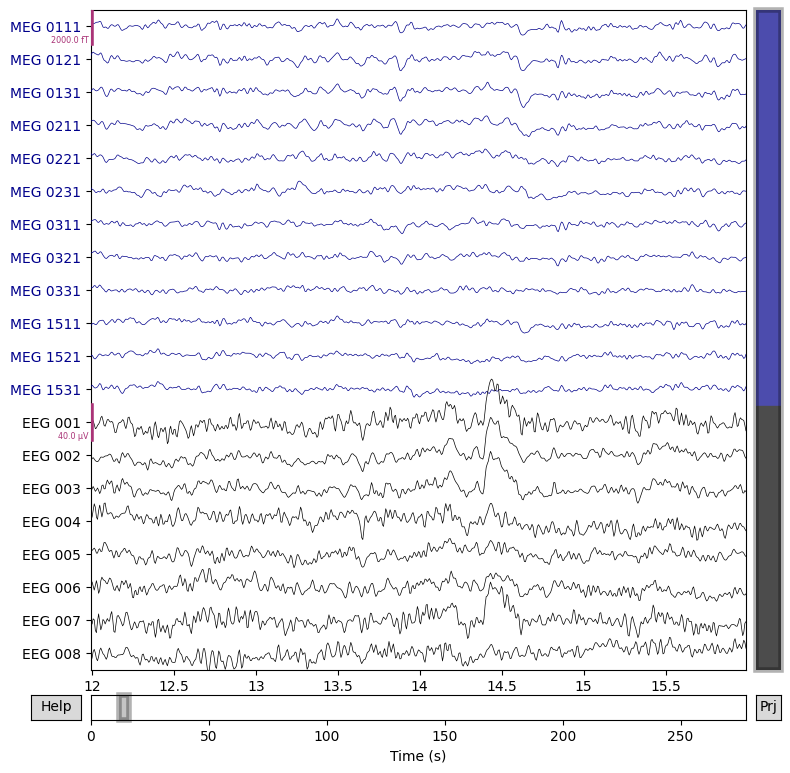

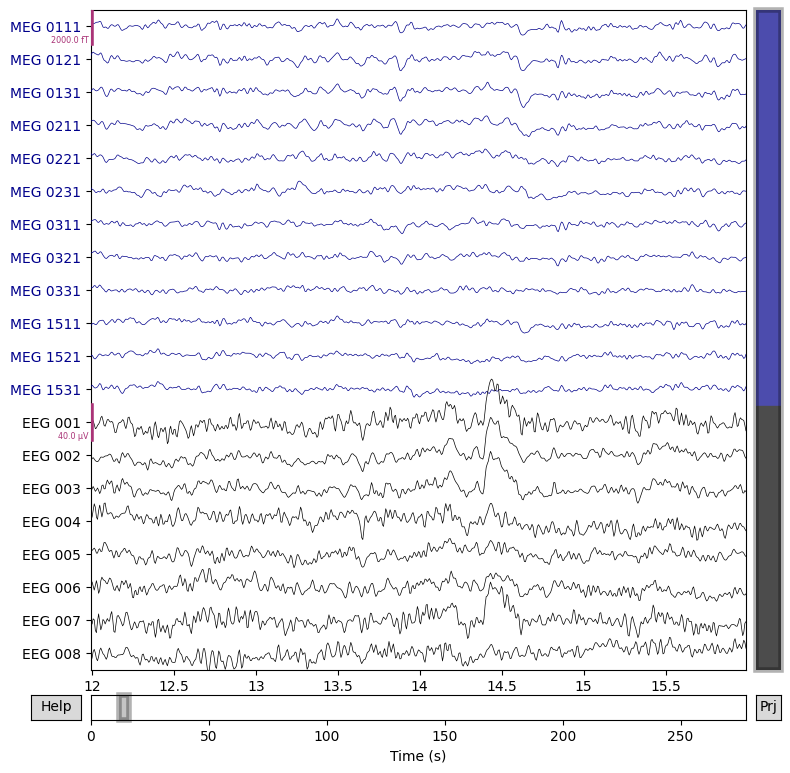

In [11]:
# プログラム5

orig_raw = raw.copy()
raw.load_data()
ica.apply(raw)

# show some frontal channels to clearly illustrate the artifact removal
chs = [
    "MEG 0111",
    "MEG 0121",
    "MEG 0131",
    "MEG 0211",
    "MEG 0221",
    "MEG 0231",
    "MEG 0311",
    "MEG 0321",
    "MEG 0331",
    "MEG 1511",
    "MEG 1521",
    "MEG 1531",
    "EEG 001",
    "EEG 002",
    "EEG 003",
    "EEG 004",
    "EEG 005",
    "EEG 006",
    "EEG 007",
    "EEG 008",
]
chan_idxs = [raw.ch_names.index(ch) for ch in chs]
orig_raw.plot(order=chan_idxs, start=12, duration=4)
raw.plot(order=chan_idxs, start=12, duration=4)

### 実験イベントの検出

In [12]:
# プログラム6

events = mne.find_events(raw, stim_channel="STI 014")
print(events[:5])  # show the first 5

Finding events on: STI 014
319 events found on stim channel STI 014
Event IDs: [ 1  2  3  4  5 32]
[[6994    0    2]
 [7086    0    3]
 [7192    0    1]
 [7304    0    4]
 [7413    0    2]]


In [13]:
# プログラム7

event_dict = {
    "auditory/left": 1,
    "auditory/right": 2,
    "visual/left": 3,
    "visual/right": 4,
    "smiley": 5,
    "buttonpress": 32,
}

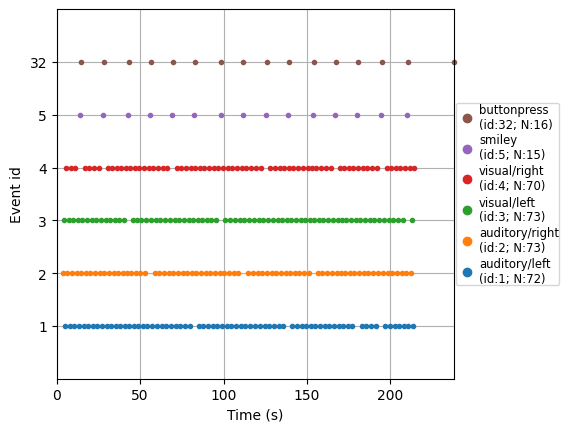

In [14]:
# プログラム8

fig = mne.viz.plot_events(
    events, event_id=event_dict, sfreq=raw.info["sfreq"], first_samp=raw.first_samp
)

### 連続データのエポック化

In [15]:
# プログラム9

reject_criteria = dict(
    mag=4000e-15,  # 4000 fT
    grad=4000e-13,  # 4000 fT/cm
    eeg=150e-6,  # 150 µV
    eog=250e-6,
)  # 250 µV

In [16]:
# プログラム10

epochs = mne.Epochs(
    raw,
    events,
    event_id=event_dict,
    tmin=-0.2,
    tmax=0.5,
    reject=reject_criteria,
    preload=True,
)

Not setting metadata
319 matching events found
Setting baseline interval to [-0.19979521315838786, 0.0] s
Applying baseline correction (mode: mean)
Created an SSP operator (subspace dimension = 4)
4 projection items activated
Using data from preloaded Raw for 319 events and 106 original time points ...
    Rejecting  epoch based on EOG : ['EOG 061']
    Rejecting  epoch based on EOG : ['EOG 061']
    Rejecting  epoch based on MAG : ['MEG 1711']
    Rejecting  epoch based on EOG : ['EOG 061']
    Rejecting  epoch based on EOG : ['EOG 061']
    Rejecting  epoch based on MAG : ['MEG 1711']
    Rejecting  epoch based on EEG : ['EEG 008']
    Rejecting  epoch based on EOG : ['EOG 061']
    Rejecting  epoch based on EOG : ['EOG 061']
    Rejecting  epoch based on EOG : ['EOG 061']
10 bad epochs dropped


In [17]:
# プログラム11

conds_we_care_about = ["auditory/left", "auditory/right", "visual/left", "visual/right"]
epochs.equalize_event_counts(conds_we_care_about)  # this operates in-place
aud_epochs = epochs["auditory"]
vis_epochs = epochs["visual"]
del raw, epochs  # free up memory

Dropped 7 epochs: 121, 195, 258, 271, 273, 274, 275


Not setting metadata
136 matching events found
No baseline correction applied
0 projection items activated
Not setting metadata
136 matching events found
No baseline correction applied
0 projection items activated


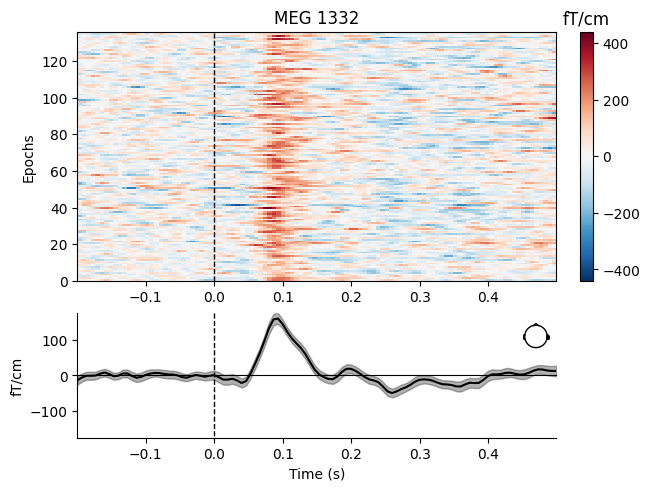

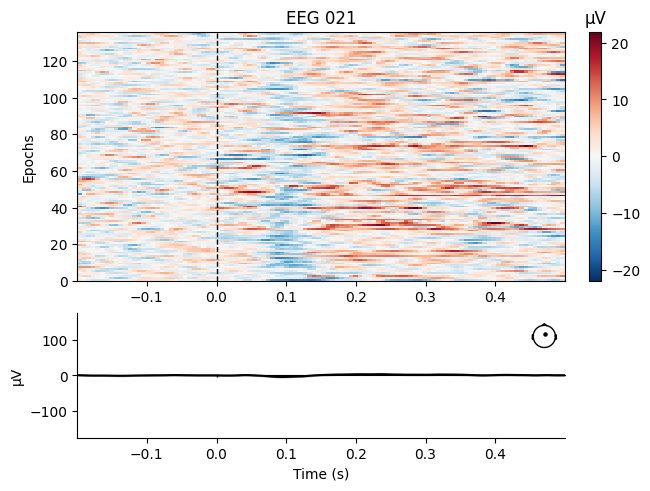

[<Figure size 640x480 with 4 Axes>, <Figure size 640x480 with 4 Axes>]

In [18]:
# プログラム12

aud_epochs.plot_image(picks=["MEG 1332", "EEG 021"])

### 時間周波数解析

No baseline correction applied


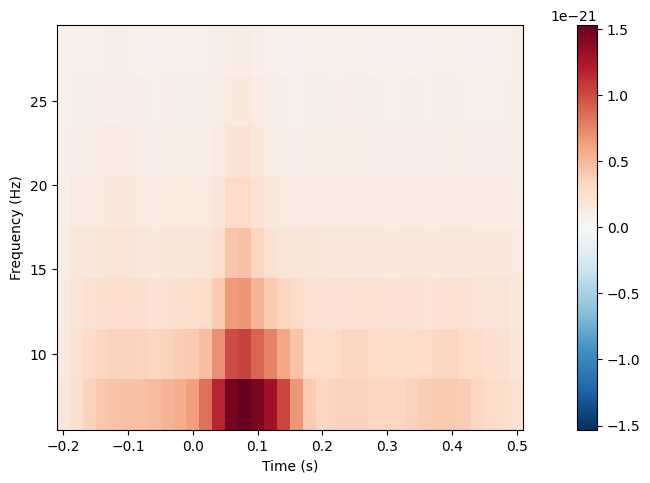

[<Figure size 640x480 with 2 Axes>]

In [22]:
# プログラム13

frequencies = np.arange(7, 30, 3)
power = aud_epochs.compute_tfr(
    "morlet", n_cycles=2, return_itc=False, freqs=frequencies, decim=3, average=True
)
power.plot(["MEG 1332"])

### 誘発反応の推定

Multiple channel types selected, returning one figure per type.
combining channels using RMS (grad channels)
combining channels using RMS (grad channels)


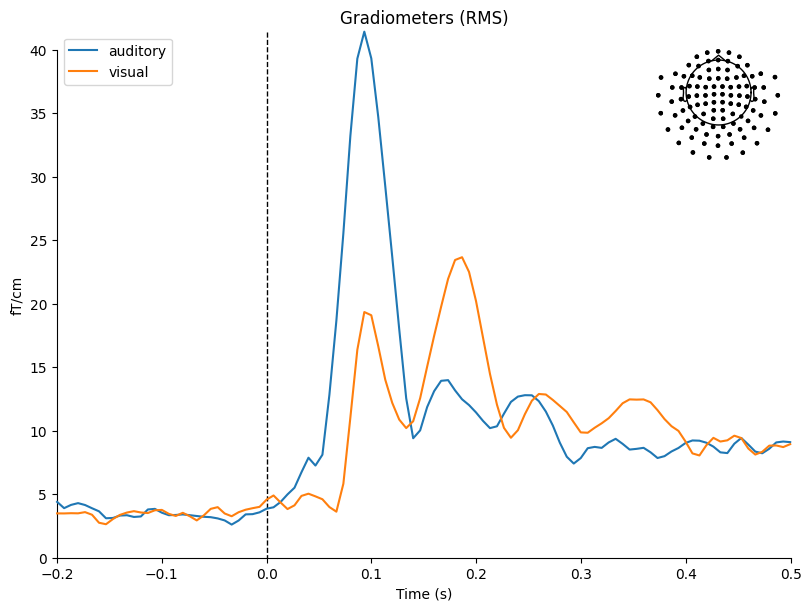

combining channels using RMS (mag channels)
combining channels using RMS (mag channels)


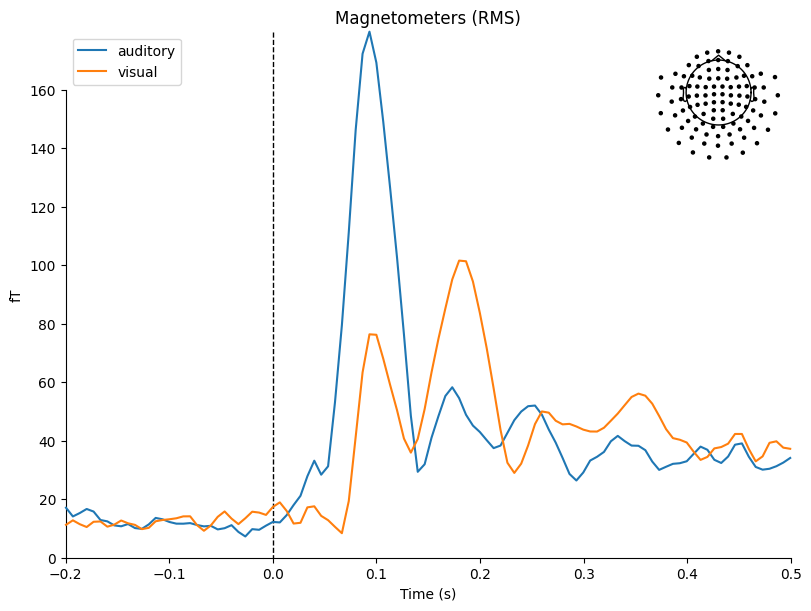

combining channels using GFP (eeg channels)
combining channels using GFP (eeg channels)


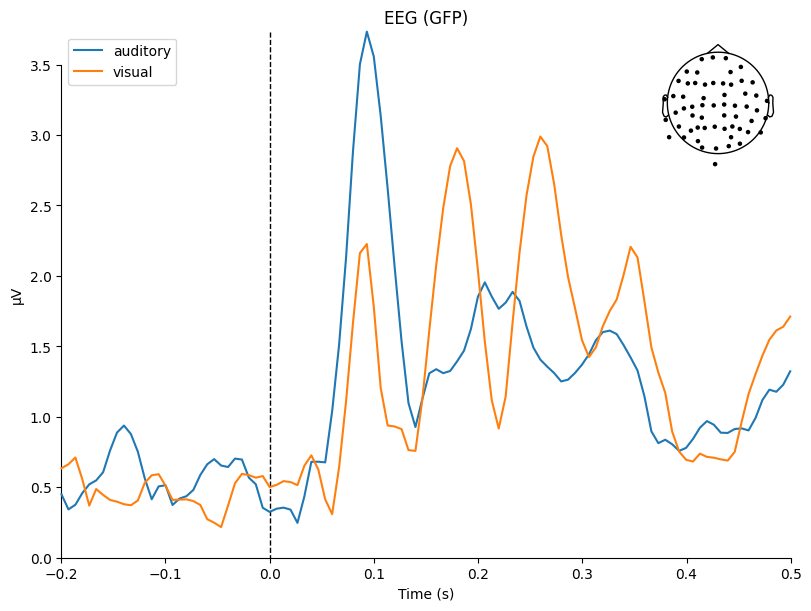

[<Figure size 800x600 with 2 Axes>,
 <Figure size 800x600 with 2 Axes>,
 <Figure size 800x600 with 2 Axes>]

In [23]:
# プログラム14

aud_evoked = aud_epochs.average()
vis_evoked = vis_epochs.average()

mne.viz.plot_compare_evokeds(
    dict(auditory=aud_evoked, visual=vis_evoked),
    legend="upper left",
    show_sensors="upper right",
)

Projections have already been applied. Setting proj attribute to True.


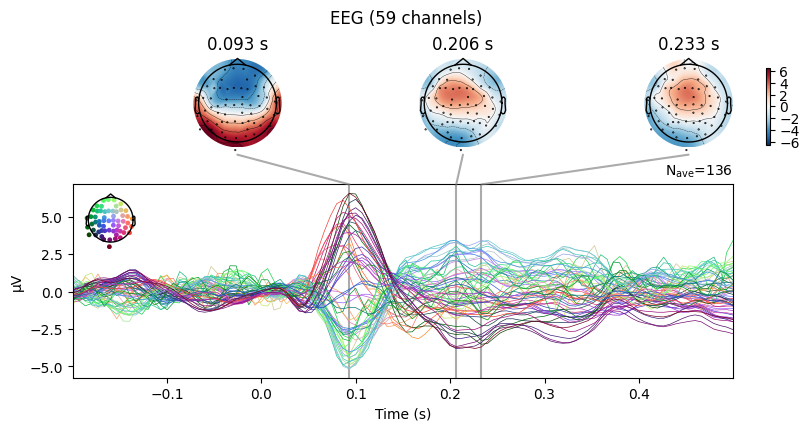

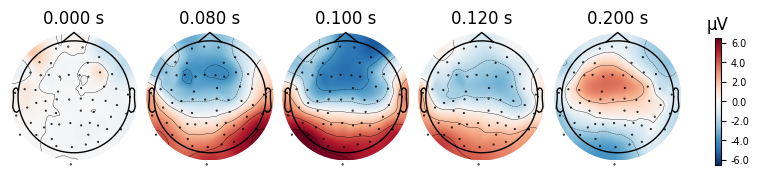

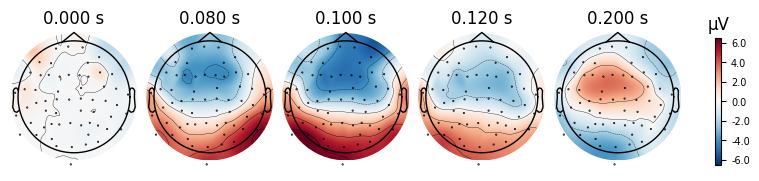

In [24]:
# プログラム15

aud_evoked.plot_joint(picks="eeg")
aud_evoked.plot_topomap(times=[0.0, 0.08, 0.1, 0.12, 0.2], ch_type="eeg")

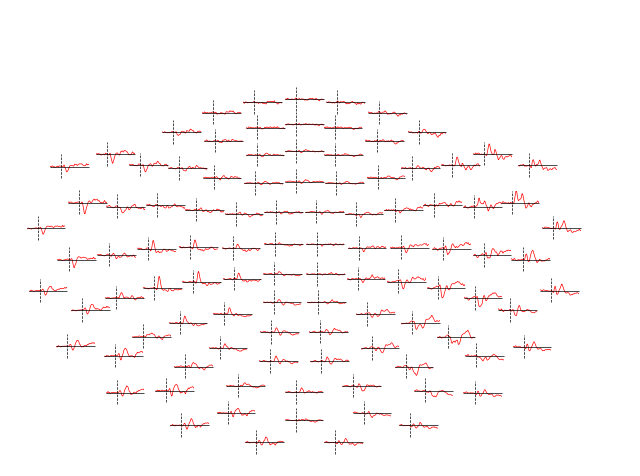

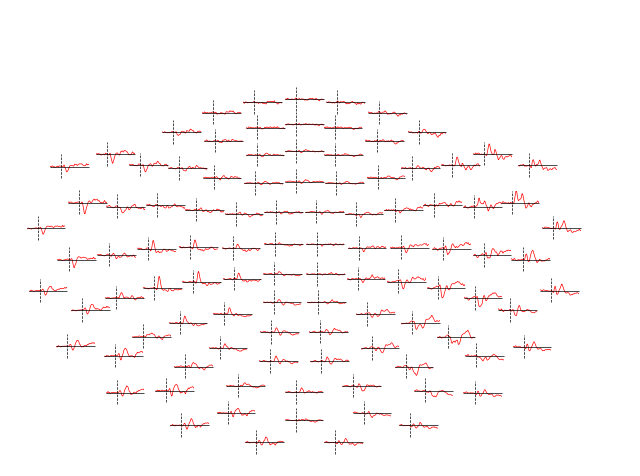

In [25]:
# プログラム16

evoked_diff = mne.combine_evoked([aud_evoked, vis_evoked], weights=[1, -1])
evoked_diff.pick(picks="mag").plot_topo(color="r", legend=False)

### 逆モデリング

In [26]:
# プログラム17

# load inverse operator
inverse_operator_file = (
    sample_data_folder / "MEG" / "sample" / "sample_audvis-meg-oct-6-meg-inv.fif"
)
inv_operator = mne.minimum_norm.read_inverse_operator(inverse_operator_file)
# set signal-to-noise ratio (SNR) to compute regularization parameter (λ²)
snr = 3.0
lambda2 = 1.0 / snr**2
# generate the source time course (STC)
stc = mne.minimum_norm.apply_inverse(
    vis_evoked, inv_operator, lambda2=lambda2, method="MNE"
)  # or dSPM, sLORETA, eLORETA

Reading inverse operator decomposition from /Users/r.shimbo/mne_data/MNE-sample-data/MEG/sample/sample_audvis-meg-oct-6-meg-inv.fif...
    Reading inverse operator info...
    [done]
    Reading inverse operator decomposition...
    [done]
    305 x 305 full covariance (kind = 1) found.
    Read a total of 4 projection items:
        PCA-v1 (1 x 102) active
        PCA-v2 (1 x 102) active
        PCA-v3 (1 x 102) active
        Average EEG reference (1 x 60) active
    Noise covariance matrix read.
    22494 x 22494 diagonal covariance (kind = 2) found.
    Source covariance matrix read.
    22494 x 22494 diagonal covariance (kind = 6) found.
    Orientation priors read.
    22494 x 22494 diagonal covariance (kind = 5) found.
    Depth priors read.
    Did not find the desired covariance matrix (kind = 3)
    Reading a source space...
    Computing patch statistics...
    Patch information added...
    Distance information added...
    [done]
    Reading a source space...
    Computing

In [28]:
# プログラム18

# path to subjects' MRI files
subjects_dir = sample_data_folder / "subjects"
# plot the STC
stc.plot(
    initial_time=0.1, hemi="split", views=["lat", "med"], subjects_dir=subjects_dir
)

Using control points [8.61922423e-11 1.06837855e-10 4.49139511e-10]
For automatic theme detection, "darkdetect" has to be installed! You can install it with `pip install darkdetect`
For automatic theme detection, "darkdetect" has to be installed! You can install it with `pip install darkdetect`
For automatic theme detection, "darkdetect" has to be installed! You can install it with `pip install darkdetect`
For automatic theme detection, "darkdetect" has to be installed! You can install it with `pip install darkdetect`


2026-04-18 22:03:32.072 python[49420:16332383] error messaging the mach port for IMKCFRunLoopWakeUpReliable
